#IIDS67692 Computational Techniques for Multi-modal Data
#Lab: Multimodal Large Language Model

In this lab, we will be exploring different fusion techniques in a Multimodal Large Language Model for Health Decision Support

this is my assignment

###Installing required python packages

In [1]:
!pip install -q evaluate bert_score rouge_score --upgrade torchao

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 79.2 MB/s eta 0:00:00


#Dataset



Huggingface Link: https://huggingface.co/datasets/flaviagiammarino/path-vqa

The PathVQA Dataset is available on Hugging Face and contains 19,654 training, 6,259 validation, and 6,719 test question-answer pairs across approximately 5,004 pathology images.

The PathVQA Dataset is a large-scale medical visual question answering benchmark designed for pathology image understanding. It contains more than 32,000 question-answer pairs associated with pathology images collected from publicly available medical sources. The dataset supports multimodal AI research by combining visual pathology information with natural language reasoning tasks, enabling models to answer clinically relevant questions about tissue appearance, disease characteristics, and diagnostic findings. PathVQA has become a widely used benchmark for evaluating medical VQA systems and multimodal large language models in digital pathology research.

[1] He, Xuehai, et al. "Towards visual question answering on pathology images." Proceedings of the 59th Annual Meeting of the Association for Computational Linguistics and the 11th International Joint Conference on Natural Language Processing (Volume 2: Short Papers). 2021.

[2] He, Xuehai, et al. "Pathvqa: 30000+ questions for medical visual question answering." arXiv preprint arXiv:2003.10286 (2020)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


data/validation-00000-of-00003-90a5518d2(…):   0%|          | 0.00/41.3M [00:00<?, ?B/s]

data/validation-00001-of-00003-cbfe947a3(…):   0%|          | 0.00/45.7M [00:00<?, ?B/s]

data/validation-00002-of-00003-9ec816895(…):   0%|          | 0.00/64.7M [00:00<?, ?B/s]

Generating validation split: 0 examples [00:00, ? examples/s]

samplesize: 6259
dict_keys(['image', 'question', 'answer'])
image reso;ution: (205, 315, 4)


Text(0.5, 1.0, 'Q: what is acute viral hepatitis characterized by?\nA: predominantly lymphocytic infiltrate')

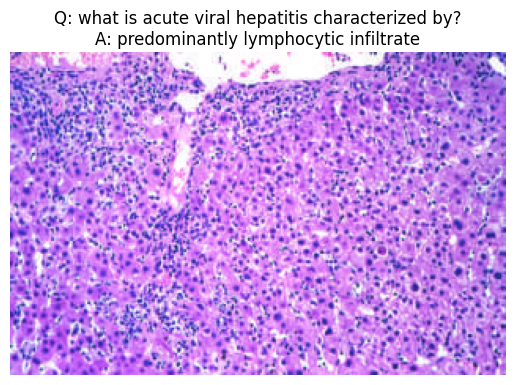

In [2]:
from datasets import load_dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
plt.axis('off')

pathvqa_valid = load_dataset("parquet", data_files={"validation": "hf://datasets/flaviagiammarino/path-vqa/data/validation-*.parquet"}, split="validation")
print('samplesize:', len(pathvqa_valid))
idx=3
print(pathvqa_valid[idx].keys())
print('image reso;ution:', np.array(pathvqa_valid[idx]['image']).shape)
plt.imshow(pathvqa_valid[idx]['image'])
plt.title(f'Q: {pathvqa_valid[idx]['question']}\nA: {pathvqa_valid[idx]['answer']}', fontsize=12)


#Prepare Dataloader

split: train = 2400 and test=600
Sample size: Training: 2400 validation: 600
image resolution: torch.Size([3, 224, 224])


Text(0.5, 1.0, 'Q: is gross islands of tumor?\nA: yes')

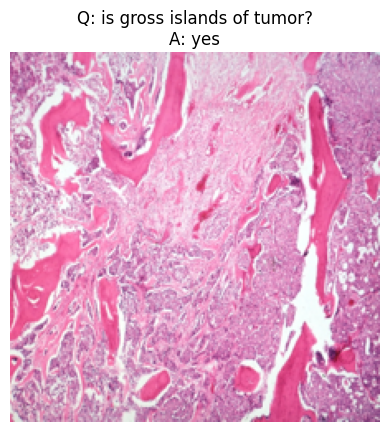

In [8]:
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader


class PathVQADataset(Dataset):
    def __init__(self, hf_dataset):
        """
        hf_dataset: HuggingFace dataset (already loaded split)
        """

        self.dataset = hf_dataset

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        # --- Image ---
        # HF dataset already provides PIL image
        raw_image = sample["image"].convert('RGB')
        img = self.transform(raw_image)

        # --- Question & Answer ---
        question = sample["question"]
        answer = sample["answer"]

        return img, question, answer

subset = pathvqa_valid.shuffle(seed=42).select(range(3000))
split_dataset = subset.train_test_split(test_size=0.2, seed=42)

# split_dataset = pathvqa_valid.train_test_split(test_size=0.2, seed=42)

train_data = split_dataset["train"]
val_data   = split_dataset["test"]
print(f'split: train = {len(train_data)} and test={len(val_data)}')

train_dataset = PathVQADataset(train_data)
val_dataset   = PathVQADataset(val_data)
print('Sample size: Training:', len(train_dataset), 'validation:', len(val_dataset))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)


img, question, answer = train_dataset[1]
print('image resolution:', img.size())
plt.axis('OFF')
plt.imshow(img.permute(1,2,0))
plt.title(f'Q: {question}\nA: {answer}', fontsize=12)

#Calculate Max Length

In [9]:
from tqdm import tqdm
from transformers import GPT2Tokenizer

# init tokenizer and model
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

def compute_max_length(dataset, tokenizer):
    max_len = 0

    for sample in dataset:
        question = sample["question"]
        answer = sample["answer"]

        text = f"Question: {question} Answer: {answer}"

        tokens = tokenizer(
            text,
            add_special_tokens=False
        )["input_ids"]

        if len(tokens) > max_len:
            max_len = len(tokens)

    return max_len

max_len = compute_max_length(pathvqa_valid, tokenizer)
print("Max token length:", max_len)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Max token length: 68


#Model Architecture

Paper: https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf

GPT-2 uses a decoder-only transformer architecture with multiple model sizes; the commonly used GPT-2 Base model contains 12 transformer blocks (layers), a context window of 1024 tokens, a hidden embedding size of 768, and about 117 million parameters, while larger variants scale up to 48 transformer blocks and 1.5 billion parameters.

[1] Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., & Sutskever, I. (2019). Language models are unsupervised multitask learners. OpenAI blog, 1(8), 9.

### Cross-Attention fusion

In [17]:
import math
import torch
import torch.nn as nn
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ViTModel, BlipTextModel
from peft import get_peft_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class CrossAttentionFusion(nn.Module):
    def __init__(self, hidden_dim=768, num_heads=8, dropout=0.1):
        super().__init__()

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)

        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.Dropout(dropout)
        )

    def forward(self, text_embeds, image_embeds, text_att_mask=None):
        """
        text_embeds:  [B, T, 768]
        image_embeds: [B, N, 768]
        text attends to image
        """

        attended_text, attn_weights = self.cross_attn(
            query=text_embeds,
            key=image_embeds,
            value=image_embeds,
            need_weights=False
        )

        x = self.norm1(text_embeds + attended_text)
        x = self.norm2(x + self.ffn(x))

        return x


class MedVQA(nn.Module):
    def __init__(self, peft_config=None):
        super(MedVQA, self).__init__()

        # visual encoder
        model_name = "google/vit-base-patch16-224-in21k"
        self.visual_encoder = ViTModel.from_pretrained(model_name)

        # Freeze all parameters in visual encoder
        for param in self.visual_encoder.parameters():
            param.requires_grad = False

        # tokenizer
        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.tokenizer.pad_token = self.tokenizer.eos_token  # end of string

        # gpt2 decoder
        gpt = GPT2LMHeadModel.from_pretrained('gpt2')
        self.gpt = get_peft_model(gpt, peft_config)
        # self.gpt.print_trainable_parameters()  # Verify trainable LoRA parameters
        self.fusion = CrossAttentionFusion(
            hidden_dim=768,
            num_heads=4
        )

    def forward(self, image, qa_inputs_ids, qa_att_mask):
        image_embeds = self.visual_encoder(image).last_hidden_state
        # [B, 197, 768]

        # text_embeds = self.gpt.base_model.model.transformer.wte(qa_inputs_ids)
        text_embeds = self.gpt.get_input_embeddings()(qa_inputs_ids)
        # [B, T, 768]

        fused_embeds = self.fusion(
            text_embeds=text_embeds,
            image_embeds=image_embeds,
            text_att_mask=qa_att_mask
        )
        # [B, T, 768]

        gpt_output = self.gpt(
            inputs_embeds=fused_embeds,
            attention_mask=qa_att_mask
        )
        return gpt_output.logits

#### Outcome for CA Training Loss: 2.009156
model params:  218727936
Start training.
Training - Epoch: 1/5, Iteration: 0/75, AVG Training Loss: 8.989950
Training - Epoch: 1/5, Iteration: 50/75, AVG Training Loss: 5.180254
Best validation loss, model saved.

Training - Epoch: 2/5, Iteration: 0/75, AVG Training Loss: 3.325119
Training - Epoch: 2/5, Iteration: 50/75, AVG Training Loss: 3.287604
Best validation loss, model saved.

Training - Epoch: 3/5, Iteration: 0/75, AVG Training Loss: 3.429493
Training - Epoch: 3/5, Iteration: 50/75, AVG Training Loss: 2.730584
Best validation loss, model saved.

Training - Epoch: 4/5, Iteration: 0/75, AVG Training Loss: 2.009156
Training - Epoch: 4/5, Iteration: 50/75, AVG Training Loss: 2.437895
Best validation loss, model saved.

Training - Epoch: 5/5, Iteration: 0/75, AVG Training Loss: 2.734643
Training - Epoch: 5/5, Iteration: 50/75, AVG Training Loss: 2.163681
Best validation loss, model saved.
End training.

### GATE Cross-Attention fusion

In [ ]:
import math
import torch
import torch.nn as nn
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ViTModel, BlipTextModel
from peft import get_peft_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class GatedCrossAttentionFusion(nn.Module):
    def __init__(self, hidden_dim=768, num_heads=8, dropout=0.1):
        super().__init__()

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Sigmoid()
        )

        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)

        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.Dropout(dropout)
        )

    def forward(self, text_embeds, image_embeds, text_att_mask=None):
        """
        text_embeds:  [B, T, 768]
        image_embeds: [B, N, 768]
        text attends to image
        """

        attended_text, attn_weights = self.cross_attn(
            query=text_embeds,
            key=image_embeds,
            value=image_embeds,
            need_weights=False
        )

        gate_input = torch.cat([text_embeds, attended_text], dim=-1)
        gate_value = self.gate(gate_input)


        x = text_embeds + gate_value * attended_text
        x = self.norm1(x)

        # x = self.norm1(text_embeds + attended_text)
        x = self.norm2(x + self.ffn(x))

        return x


class MedVQA(nn.Module):
    def __init__(self, peft_config=None):
        super(MedVQA, self).__init__()

        # visual encoder
        model_name = "google/vit-base-patch16-224-in21k"
        self.visual_encoder = ViTModel.from_pretrained(model_name)

        # Freeze all parameters in visual encoder
        for param in self.visual_encoder.parameters():
            param.requires_grad = False

        # tokenizer
        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.tokenizer.pad_token = self.tokenizer.eos_token  # end of string

        # gpt2 decoder
        gpt = GPT2LMHeadModel.from_pretrained('gpt2')
        self.gpt = get_peft_model(gpt, peft_config)
        # self.gpt.print_trainable_parameters()  # Verify trainable LoRA parameters
        # self.fusion = CrossAttentionFusion(
        #     hidden_dim=768,
        #     num_heads=4
        # )

        self.fusion = GatedCrossAttentionFusion(hidden_dim=768, num_heads=4)


    def forward(self, image, qa_inputs_ids, qa_att_mask):
        image_embeds = self.visual_encoder(image).last_hidden_state
        # [B, 197, 768]

        # text_embeds = self.gpt.base_model.model.transformer.wte(qa_inputs_ids)
        text_embeds = self.gpt.get_input_embeddings()(qa_inputs_ids)
        # [B, T, 768]

        fused_embeds = self.fusion(
            text_embeds=text_embeds,
            image_embeds=image_embeds,
            text_att_mask=qa_att_mask
        )
        # [B, T, 768]

        gpt_output = self.gpt(
            inputs_embeds=fused_embeds,
            attention_mask=qa_att_mask
        )
        return gpt_output.logits

#### Outcome for Gate CA Training Loss: 1.984432
model params:  219908352
Start training.
Training - Epoch: 1/5, Iteration: 0/75, AVG Training Loss: 8.772306
Training - Epoch: 1/5, Iteration: 50/75, AVG Training Loss: 4.908609
Best validation loss, model saved.

Training - Epoch: 2/5, Iteration: 0/75, AVG Training Loss: 3.170253
Training - Epoch: 2/5, Iteration: 50/75, AVG Training Loss: 3.167288
Best validation loss, model saved.

Training - Epoch: 3/5, Iteration: 0/75, AVG Training Loss: 2.331666
Training - Epoch: 3/5, Iteration: 50/75, AVG Training Loss: 2.812986
Best validation loss, model saved.

Training - Epoch: 4/5, Iteration: 0/75, AVG Training Loss: 2.739895
Training - Epoch: 4/5, Iteration: 50/75, AVG Training Loss: 2.526281
Best validation loss, model saved.

Training - Epoch: 5/5, Iteration: 0/75, AVG Training Loss: 1.984432
Training - Epoch: 5/5, Iteration: 50/75, AVG Training Loss: 2.132617
Best validation loss, model saved.
End training.

### Parallel Cross Attention fusion
reference: https://medium.com/@heyamit10/implement-self-attention-and-cross-attention-in-pytorch-cfe17ab0b3ee
https://deepwiki.com/lucidrains/flamingo-pytorch/3.2-gatedcrossattentionblock


In [ ]:
import math
import torch
import torch.nn as nn
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ViTModel, BlipTextModel
from peft import get_peft_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class ParallelCrossAttentionFusion(nn.Module):
    def __init__(self, hidden_dim=768, num_heads=8, dropout=0.1):
        super().__init__()

        # text attends to image
        self.t2i_attn = nn.MultiheadAttention(
            hidden_dim, num_heads, dropout=dropout, batch_first=True
        )

        # image attends to text (parallel branch)
        self.i2t_attn = nn.MultiheadAttention(
            hidden_dim, num_heads, dropout=dropout, batch_first=True
        )

        self.norm_t = nn.LayerNorm(hidden_dim)
        self.norm_i = nn.LayerNorm(hidden_dim)
        self.norm_fused = nn.LayerNorm(hidden_dim)

        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.Dropout(dropout)
        )

    def forward(self, text_embeds, image_embeds, text_att_mask=None):
        """
        text_embeds:  [B, T, 768]
        image_embeds: [B, N, 768]
        """

        # Text → Image
        t2i, _ = self.t2i_attn(
            query=text_embeds,
            key=image_embeds,
            value=image_embeds
        )
        t2i = self.norm_t(text_embeds + t2i)

        # Image → Text (parallel)
        i2t, _ = self.i2t_attn(
            query=image_embeds,
            key=text_embeds,
            value=text_embeds
        )
        i2t = self.norm_i(image_embeds + i2t)

        # i2t information back to text space
        i2t_pooled = i2t.mean(dim=1, keepdim=True)   # [B, 1, D]
        i2t_pooled = i2t_pooled.expand(-1, t2i.size(1), -1)

        fused = self.norm_fused(t2i + i2t_pooled)
        fused = fused + self.ffn(fused)

        return fused



class MedVQA(nn.Module):
    def __init__(self, peft_config=None):
        super(MedVQA, self).__init__()

        # visual encoder
        model_name = "google/vit-base-patch16-224-in21k"
        self.visual_encoder = ViTModel.from_pretrained(model_name)

        # Freeze all parameters in visual encoder
        for param in self.visual_encoder.parameters():
            param.requires_grad = False

        # tokenizer
        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.tokenizer.pad_token = self.tokenizer.eos_token  # end of string

        # gpt2 decoder
        gpt = GPT2LMHeadModel.from_pretrained('gpt2')
        self.gpt = get_peft_model(gpt, peft_config)
        # self.gpt.print_trainable_parameters()  # Verify trainable LoRA parameters
        self.fusion = ParallelCrossAttentionFusion(
            hidden_dim=768,
            num_heads=4
        )

    def forward(self, image, qa_inputs_ids, qa_att_mask):
        image_embeds = self.visual_encoder(image).last_hidden_state
        # [B, 197, 768]

        # text_embeds = self.gpt.base_model.model.transformer.wte(qa_inputs_ids)
        text_embeds = self.gpt.get_input_embeddings()(qa_inputs_ids)
        # [B, T, 768]

        fused_embeds = self.fusion(text_embeds, image_embeds
        )
        # [B, T, 768]

        gpt_output = self.gpt(
            inputs_embeds=fused_embeds,
            attention_mask=qa_att_mask
        )
        return gpt_output.logits

#### Outcome for parallel Training Loss: 1.805971
model params:  221091840
Start training.
Training - Epoch: 1/5, Iteration: 0/75, AVG Training Loss: 9.106909
Training - Epoch: 1/5, Iteration: 50/75, AVG Training Loss: 5.269410
Best validation loss, model saved.
Training - Epoch: 2/5, Iteration: 0/75, AVG Training Loss: 3.901984
Training - Epoch: 2/5, Iteration: 50/75, AVG Training Loss: 3.367663
Best validation loss, model saved.
Training - Epoch: 3/5, Iteration: 0/75, AVG Training Loss: 3.322936
Training - Epoch: 3/5, Iteration: 50/75, AVG Training Loss: 2.837160
Best validation loss, model saved.
Training - Epoch: 4/5, Iteration: 0/75, AVG Training Loss: 2.572100
Training - Epoch: 4/5, Iteration: 50/75, AVG Training Loss: 2.420528
Best validation loss, model saved.
Training - Epoch: 5/5, Iteration: 0/75, AVG Training Loss: 1.805971
Training - Epoch: 5/5, Iteration: 50/75, AVG Training Loss: 2.088429
Best validation loss, model saved.
End training.

### CLIP (Contrastive Language-Image Pre-Training)
reference:
https://github.com/openai/CLIP/blob/main/clip/model.py


In [4]:
 pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-_87ocpk5
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-_87ocpk5
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=1edbc4fcb050a9753477baa4a54ea157eb675e5d07a675a2d3a9d08b7bb0b785
  Stored in directory: /tmp/pip-ephem-wheel-cache-t44h_uen/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [5]:
import torch
import torch.nn as nn
import clip
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from peft import get_peft_model

In [13]:
class CrossAttentionFusion(nn.Module):
    def __init__(self, hidden_dim=768, num_heads=8, dropout=0.1):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.Dropout(dropout)
        )

    def forward(self, text_embeds, image_embeds, text_att_mask=None):
        attended_text, _ = self.cross_attn(
            query=text_embeds,
            key=image_embeds,
            value=image_embeds,
            need_weights=False
        )
        x = self.norm1(text_embeds + attended_text)
        x = self.norm2(x + self.ffn(x))
        return x


class CLIPVisionTokenEncoder(nn.Module):
    """
    conv1 -> reshape/permute -> concat class_embedding -> add positional_embedding
    -> ln_pre -> transformer (LND) -> NLD
    """
    def __init__(self, clip_model):
        super().__init__()
        self.visual = clip_model.visual  # VisionTransformer or ModifiedResNet
        self.clip_dtype = clip_model.dtype

    @property
    def width(self):
        # ViT token width = conv1 out_channels
        return self.visual.conv1.weight.shape[0]

    def forward(self, images):
        v = self.visual

        # 1) patch embedding: conv1(kernel=patch_size, stride=patch_size)
        x = v.conv1(images.type(self.clip_dtype))         # [B, width, grid, grid]
        x = x.reshape(x.shape[0], x.shape[1], -1)         # [B, width, grid^2]
        x = x.permute(0, 2, 1)                            # [B, grid^2, width]

        # 2) prepend CLS token (class_embedding)
        cls = v.class_embedding.to(x.dtype) + torch.zeros(
            x.shape[0], 1, x.shape[-1], dtype=x.dtype, device=x.device
        )
        x = torch.cat([cls, x], dim=1)                    # [B, 1+grid^2, width]

        # 3) add positional embedding + ln_pre
        x = x + v.positional_embedding.to(x.dtype)        # [B, 1+grid^2, width]
        x = v.ln_pre(x)

        # 4) transformer expects LND
        x = x.permute(1, 0, 2)                            # [L, B, D]
        x = v.transformer(x)
        x = x.permute(1, 0, 2)                            # [B, L, D]

        x = v.ln_post(x)

        return x  # [B, 1+grid^2, width]


class MedVQA(nn.Module):
    def __init__(self, peft_config=None, clip_name="ViT-B/32"):
        super().__init__()

        # 1) Load OpenAI CLIP (model defined in clip/model.py)
        self.clip_model, self.clip_preprocess = clip.load(clip_name, device=device, jit=False)
        self.clip_model.eval()
        for p in self.clip_model.parameters():
            p.requires_grad = False

        # 2) CLIP vision tokens
        self.vision_tokenizer = CLIPVisionTokenEncoder(self.clip_model)

        # 3) GPT2 tokenizer + decoder
        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.tokenizer.pad_token = self.tokenizer.eos_token

        gpt = GPT2LMHeadModel.from_pretrained('gpt2')
        self.gpt = get_peft_model(gpt, peft_config)

        gpt_dim = self.gpt.config.n_embd

        # 4) if CLIP vision width != GPT2 dim, project
        vision_width = self.vision_tokenizer.width
        self.vision_to_gpt = nn.Identity() if vision_width == gpt_dim else nn.Linear(vision_width, gpt_dim)

        # 5) fusion block
        self.fusion = CrossAttentionFusion(hidden_dim=gpt_dim, num_heads=4)

    def forward(self, image, qa_inputs_ids, qa_att_mask):
        text_embeds = self.gpt.get_input_embeddings()(qa_inputs_ids)  # [B, T, 768]

        image_tokens = self.vision_tokenizer(image)            # [B, N, vision_width]
        image_tokens = self.vision_to_gpt(image_tokens)        # [B, N, 768]
        image_tokens = image_tokens.to(text_embeds.dtype)

        fused_embeds = self.fusion(
            text_embeds=text_embeds,
            image_embeds=image_tokens,
            text_att_mask=qa_att_mask
        )  # [B, T, 768]

        gpt_output = self.gpt(
            inputs_embeds=fused_embeds,
            attention_mask=qa_att_mask
        )
        return gpt_output.logits

#### Outcome for CLIP Training Loss: 1.623137
model params:  283616001
Start training.
Training - Epoch: 1/5, Iteration: 0/75, AVG Training Loss: 9.206244
Training - Epoch: 1/5, Iteration: 50/75, AVG Training Loss: 5.985946
Best validation loss, model saved.
Training - Epoch: 2/5, Iteration: 0/75, AVG Training Loss: 3.969636
Training - Epoch: 2/5, Iteration: 50/75, AVG Training Loss: 4.081377
Best validation loss, model saved.
Training - Epoch: 3/5, Iteration: 0/75, AVG Training Loss: 3.386415
Training - Epoch: 3/5, Iteration: 50/75, AVG Training Loss: 3.070109
Best validation loss, model saved.
Training - Epoch: 4/5, Iteration: 0/75, AVG Training Loss: 2.881303
Training - Epoch: 4/5, Iteration: 50/75, AVG Training Loss: 2.718349
Best validation loss, model saved.
Training - Epoch: 5/5, Iteration: 0/75, AVG Training Loss: 1.623137
Training - Epoch: 5/5, Iteration: 50/75, AVG Training Loss: 2.399962

Epochs since last improvement: 1

End training.

#Model Training

In [18]:
import os
import torch
import argparse
import torch.utils.data
import numpy as np
import random

from torch import nn
from torch.utils.data import DataLoader
from transformers import GPT2Tokenizer

import evaluate
from nltk.translate.bleu_score import corpus_bleu
from peft import  TaskType, LoraConfig

import warnings
warnings.filterwarnings('ignore')

def adjust_learning_rate(optimizer, shrink_factor):
    print("\nDECAYING learning rate.")
    for param_group in optimizer.param_groups:
        param_group['lr'] = param_group['lr'] * shrink_factor
    print("The new learning rate is %f\n" % (optimizer.param_groups[0]['lr'],))

def train(args, train_dataloader, model, criterion, optimizer, epoch, tokenizer, device):
    model.train()
    total_loss = []

    for i, (images, questions, answers) in enumerate(train_dataloader, 0):
        # prepare prompts
        qa_prompt = [f'Question: {q}\nAnswer: {a}' for q, a in zip(questions, answers)]
        qa_prompt_inputs = tokenizer(qa_prompt, truncation=True, padding="max_length", max_length=int(args.seq_length), return_tensors="pt")

        # get labels
        labels = qa_prompt_inputs['input_ids'].clone()
        labels = labels.to(device)

        # for labels, mask question tokens and padding tokens
        for idx, q in enumerate(questions):
            q_prompt = f"Question: {q}\nAnswer: "
            q_length = len(tokenizer(q_prompt)["input_ids"]) - 1

            labels[idx, :q_length] = -100  # mask question
            eos_mask = (labels[idx] == tokenizer.eos_token_id)  # get all EOS position
            if eos_mask.sum() > 1:  # if more than 1 EOS
                first_eos_pos = eos_mask.nonzero()[0].item()  # get first EOS position
                labels[idx, (first_eos_pos+1):] = -100  # mask paddings, left one EOS

        # get logits and labels
        logits = model(
                image=images.to(device),
                qa_inputs_ids=qa_prompt_inputs['input_ids'].to(device),
                qa_att_mask=qa_prompt_inputs['attention_mask'].to(device)
        )

        # get shifted logits and labels
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = labels[:, 1:].contiguous()

        # compute loss
        shift_logits = shift_logits.view(-1, shift_logits.size(-1))
        shift_labels = shift_labels.view(-1)
        loss = criterion(shift_logits, shift_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss.append(loss.item())
        if i%50 == 0:
            print("Training - Epoch: {}/{}, Iteration: {}/{}, AVG Training Loss: {:.6f}".format(epoch, args.epochs, i, len(train_dataloader), np.array(total_loss).mean()))


def validate(args, val_loader, model, criterion, epoch, tokenizer, device):
    total_loss = []
    model.eval()
    with torch.no_grad():
        for i, (images, questions, answers) in enumerate(val_loader, 0):
            # prepare prompts
            qa_prompt = [f'Question: {q}\nAnswer: {a}' for q, a in zip(questions, answers)]
            qa_prompt_inputs = tokenizer(qa_prompt, truncation=True, padding="max_length", max_length=int(args.seq_length), return_tensors="pt")

            # get labels
            labels = qa_prompt_inputs['input_ids'].clone()
            labels = labels.to(device)

            # for labels, mask question tokens and padding tokens
            answer_starts = []
            answer_ends = []
            for idx, q in enumerate(questions):
                q_prompt = f"Question: {q}\nAnswer: "
                q_length = len(tokenizer(q_prompt)["input_ids"]) - 1
                answer_starts.append(q_length+1)

                labels[idx, :q_length] = -100  # mask question
                eos_mask = (labels[idx] == tokenizer.eos_token_id)  # get all EOS position
                if eos_mask.sum() > 1:  # if more than 1 EOS
                    first_eos_pos = eos_mask.nonzero()[0].item()  # get first EOS position
                    labels[idx, (first_eos_pos+1):] = -100  # mask paddings, left one EOS
                    answer_ends.append(first_eos_pos)

            # get logits and labels
            logits = model(
                image=images.to(device),
                qa_inputs_ids=qa_prompt_inputs['input_ids'].to(device),
                qa_att_mask=qa_prompt_inputs['attention_mask'].to(device)
            )

            # get shifted logits and labels
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()

            # compute loss
            shift_logits = shift_logits.view(-1, shift_logits.size(-1))
            shift_labels = shift_labels.view(-1)
            loss = criterion(shift_logits, shift_labels)
            total_loss.append(loss.item())

    return np.array(total_loss).mean()


def seed_everything(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)


def get_arg():
    parser = argparse.ArgumentParser(description='VisualQuestionAnswerGeneration')
    # Training parameters
    parser.add_argument('--epochs',         type=int,   default=5,   help='number of epochs to train for')
    parser.add_argument('--batch_size',     type=int,   default=24,   help='batch size')
    parser.add_argument('--workers',        type=int,   default=8,    help='for data-loading')
    parser.add_argument('--random_seed',    type=int,   default=42,   help='random seed')
    parser.add_argument('--seq_length',     type=int,   default=68,   help='sequence length for question and answer')
    parser.add_argument('--dropout', type=float, default=0.1, help='dropout')

    parser.add_argument('--dataset',        default='endo',  help='endo / pit')
    parser.add_argument('--lr',             type=float, default=0.0002,  help='0.0000001, 0.00000005')
    parser.add_argument('--checkpoint_dir', default='checkpoints/',  help='path to checkpoint')

    args = parser.parse_args([])
    return args


if __name__ == '__main__':

    args = get_arg()
    seed_everything(args.random_seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f'Batch size: {args.batch_size}')
    print(f'Learning rate: {args.lr}')
    print(f'Random seed: {args.random_seed}')
    print(f'Sequence length: {args.seq_length}')

    os.makedirs(args.checkpoint_dir, exist_ok = True)
    start_epoch = 1
    epochs_since_improvement = 0
    best_val_loss = float('inf')

    print(f'Dataset: {args.dataset}')
    train_dataloader = None
    val_dataloader = None


    train_dataset = PathVQADataset(train_data)
    val_dataset   = PathVQADataset(val_data)
    print('Sample size: Training:', len(train_dataset), 'validation:', len(val_dataset))

    train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_dataloader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

    print('Sample size: Training:', len(train_dataset), 'validation:', len(val_dataset))

    # init tokenizer and model
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token

    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["c_attn", "c_proj"]
    )

    model = MedVQA(peft_config=lora_config)
    model = model.to(device)

    # for name, param in model.named_parameters():
    #     if param.requires_grad:
    #         print(name)

    pytorch_total_params = sum(p.numel() for p in model.parameters())
    print('model params: ', pytorch_total_params)

    # init optimizer and criterion
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    criterion = nn.CrossEntropyLoss(ignore_index=-100).to(device)

    # train and validation
    print('Start training.')
    for epoch in range(start_epoch, args.epochs+1):
        if epochs_since_improvement > 0 and epochs_since_improvement % 5 == 0:
            adjust_learning_rate(optimizer, 0.8)

        # train
        train(args, train_dataloader=train_dataloader, model=model, criterion=criterion, optimizer=optimizer,
              epoch=epoch, tokenizer=tokenizer, device=device)
        # validation
        val_loss = validate(args, val_loader=val_dataloader, model=model, criterion=criterion,
                            epoch=epoch, tokenizer=tokenizer, device=device)

        if val_loss < best_val_loss:  # save model with better validation loss
            epochs_since_improvement = 0
            best_val_loss = val_loss
            save_dir = f'{args.checkpoint_dir}/best_model_ca.pth'
            torch.save(model.state_dict(), save_dir)
            model.tokenizer.save_pretrained(args.checkpoint_dir)
            print('Best validation loss, model saved.')
        else:
            epochs_since_improvement += 1
            print("\nEpochs since last improvement: %d\n" % (epochs_since_improvement,))
    print('End training.')

Batch size: 24
Learning rate: 0.0002
Random seed: 42
Sequence length: 68
Dataset: endo
Sample size: Training: 2400 validation: 600
Sample size: Training: 2400 validation: 600


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model params:  218727936
Start training.
Training - Epoch: 1/5, Iteration: 0/75, AVG Training Loss: 8.989950
Training - Epoch: 1/5, Iteration: 50/75, AVG Training Loss: 5.172412
Best validation loss, model saved.
Training - Epoch: 2/5, Iteration: 0/75, AVG Training Loss: 3.362521
Training - Epoch: 2/5, Iteration: 50/75, AVG Training Loss: 3.274506
Best validation loss, model saved.
Training - Epoch: 3/5, Iteration: 0/75, AVG Training Loss: 3.420044
Training - Epoch: 3/5, Iteration: 50/75, AVG Training Loss: 2.724709
Best validation loss, model saved.
Training - Epoch: 4/5, Iteration: 0/75, AVG Training Loss: 2.016544
Training - Epoch: 4/5, Iteration: 50/75, AVG Training Loss: 2.428930
Best validation loss, model saved.
Training - Epoch: 5/5, Iteration: 0/75, AVG Training Loss: 2.700195
Training - Epoch: 5/5, Iteration: 50/75, AVG Training Loss: 2.164214
Best validation loss, model saved.
End training.


#Download an existing weights (Avoid this if you have trained your own model)

In [ ]:
# !mkdir -p checkpoints
# !gdown 1exWB2neq--YfDMMX2ng90OVHFteXk-bG -O checkpoints/best_model_ca.pth

#Inference: few samples

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sample size: valid: 600


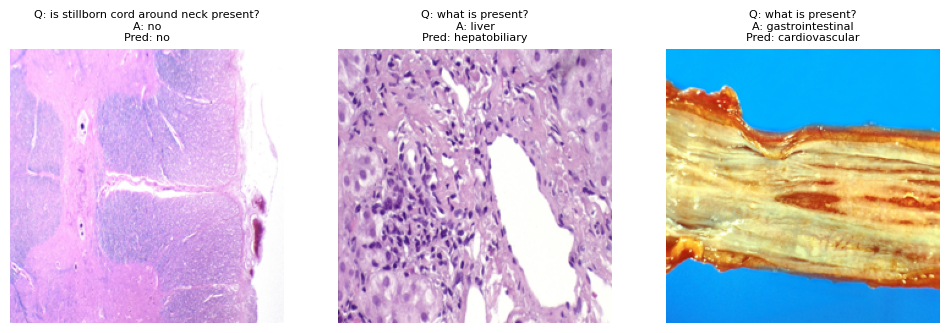

In [19]:
from tqdm import tqdm
import evaluate

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ViTModel, BlipTextModel
from peft import get_peft_model
from peft import  TaskType, LoraConfig
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

def greedy_search_single(image, question, model, tokenizer, max_length, device):
    model.eval()
    with torch.no_grad():
        # Prepare prompt and tokenize
        prompt_text = f"Question: {question}\nAnswer:"
        inputs = tokenizer(prompt_text, return_tensors="pt", add_special_tokens=False)
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)

        # Pad to max_length
        padded_input_ids = torch.zeros((1, max_length), dtype=torch.long, device=device)
        padded_attention_mask = torch.zeros((1, max_length), dtype=torch.long, device=device)
        seq_len = input_ids.size(1)
        padded_input_ids[:, :seq_len] = input_ids
        padded_attention_mask[:, :seq_len] = attention_mask

        valid_length = seq_len
        generated_ids = []

        image = image.unsqueeze(0).to(device)  # Add batch dim

        for _ in range(max_length - seq_len):
            logits = model(
                image=image,
                qa_inputs_ids=padded_input_ids[:, :valid_length],
                qa_att_mask=padded_attention_mask[:, :valid_length]
            )

            last_logits = logits[0, valid_length - 1]  # shape: [vocab_size]
            next_token_id = torch.argmax(F.softmax(last_logits, dim=-1), dim=-1)

            if next_token_id.item() == tokenizer.eos_token_id:
                break

            padded_input_ids[0, valid_length] = next_token_id
            padded_attention_mask[0, valid_length] = 1
            valid_length += 1
            generated_ids.append(next_token_id.item())

        # Decode generated tokens
        answer = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
        return answer


def inference_few_samples(sample_indices = [4, 5, 7]):
    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["c_attn", "c_proj"]
    )

    model = MedVQA(peft_config=lora_config)
    save_dir = f'checkpoints/best_model_ca.pth'
    # save_dir = f'best_model_ca_lr1.pth'
    model.load_state_dict(torch.load(save_dir, map_location=device))
    model.to(device)
    model.eval()

    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token

    val_dataset   = PathVQADataset(val_data)
    print('Sample size: valid:', len(val_dataset))

    # Create subplots
    fig, axes = plt.subplots(1, len(sample_indices), figsize=(12, 5))  # 1 row, 3 columns
    for ax, idx in zip(axes, sample_indices):
        img, question, answer_gt = val_dataset[idx]

        # Run inference
        pred_answer = greedy_search_single(img, question, model, tokenizer, max_length=34, device=device)
        img = img.permute(1, 2, 0)  # Convert from [C, H, W] to [H, W, C] for imshow
        ax.imshow(img)
        ax.set_title(f'Q: {question}\nA: {answer_gt}\nPred: {pred_answer}', fontsize=8)
        ax.axis('off')


inference_few_samples(sample_indices = [2, 80, 5])


#Inference: Metrics

In [21]:
import os
import numpy as np
import random

import torch
import torch.utils.data
from torch import nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.transforms.functional import InterpolationMode
import torch.nn as nn
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ViTModel, BlipTextModel
from peft import get_peft_model
from peft import  TaskType, LoraConfig

from PIL import Image
from tqdm import tqdm
import evaluate
rouge = evaluate.load("rouge")
import time
import math
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


def batch_greedy_search(images, questions, model, tokenizer, max_length, device):
    answers = []
    batch_size = len(questions)

    model.eval()
    with torch.no_grad():
        # Prepare the prompts for the entire batch
        prompt_texts = [f"Question: {q}\nAnswer:" for q in questions]

        # Tokenize the prompts with padding to handle varying lengths
        prompt_inputs = tokenizer(
            prompt_texts,
            return_tensors="pt",
            padding='longest',
            add_special_tokens=False
        )

        # Prepare model inputs
        padded_input_ids = torch.zeros((batch_size, max_length), dtype=torch.long, device=device)
        padded_attention_mask = torch.zeros((batch_size, max_length), device=device)

        orig_length = prompt_inputs['input_ids'].size(1)
        padded_input_ids[:, :orig_length] = prompt_inputs['input_ids'].to(device)
        padded_attention_mask[:, :orig_length] = prompt_inputs['attention_mask'].to(device)

        images = images.to(device)

        # Initialize tensors to store generated tokens
        only_answer_ids = torch.empty((batch_size, 0), dtype=torch.long, device=device)

        # Track which sequences have finished generating
        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

        # Record each sample length (number of non-eos tokens)
        valid_lengths = padded_attention_mask.sum(dim=1).long()
        batch_indices = torch.arange(batch_size, device=device)

        for _ in range(max_length - orig_length):
            max_valid_lengths = valid_lengths.max().item()

            logits = model(
                image=images,
                qa_inputs_ids=padded_input_ids[:, :max_valid_lengths],
                qa_att_mask=padded_attention_mask[:, :max_valid_lengths]
            )

            last_valid_logits = logits[batch_indices, valid_lengths - 1, :]
            next_token_ids = torch.argmax(last_valid_logits, dim=-1)

            is_eos = next_token_ids == tokenizer.eos_token_id
            finished = finished | is_eos

            padded_input_ids[batch_indices, valid_lengths] = next_token_ids
            padded_attention_mask[batch_indices, valid_lengths] = 1
            valid_lengths += 1

            only_answer_ids = torch.cat(
                [only_answer_ids, next_token_ids.unsqueeze(1)],
                dim=1
            )

            if finished.all():
                break

        # Decode the generated tokens into strings
        generated_ids_cpu = only_answer_ids.cpu().tolist()  # Move to CPU and convert to list for processing
        for i in range(batch_size):
            # Find the first occurrence of eos_token_id to truncate the answer
            try:
                eos_index = generated_ids_cpu[i].index(tokenizer.eos_token_id)
                answer_ids = generated_ids_cpu[i][:eos_index]
            except ValueError:
                # If eos_token_id is not found, use all generated tokens
                answer_ids = generated_ids_cpu[i]

            # Decode the token IDs to a string, skipping special tokens
            answer = tokenizer.decode(answer_ids, skip_special_tokens=True).strip()
            answers.append(answer)

    return answers

def validate(args, val_loader, model, tokenizer, device):
    references = []
    hypotheses = []

    model.eval()
    with torch.no_grad():
        for i, (images, questions, answers) in enumerate(tqdm(val_loader), 0):
            images = images.to(device)
            generated_answers = batch_greedy_search(
                images,
                questions,
                model,
                tokenizer,
                max_length=args.seq_length,
                device=device
            )

            references.extend(answers)
            hypotheses.extend(generated_answers)

    return references, hypotheses

def get_nlp_mettics(references, hypotheses):
    bleu = evaluate.load("bleu")
    rouge = evaluate.load("rouge")
    meteor = evaluate.load('meteor')

    # compute HF metrics
    results_bleu = bleu.compute(predictions=hypotheses, references=references)
    results_rouge = rouge.compute(predictions=hypotheses, references=references)
    results_meteor = meteor.compute(predictions=hypotheses, references=references)

    print("HuggingFace Metrics Results:")

    print(f"BLEU-1: {results_bleu['precisions'][0]:.6f}, "
      f"BLEU-2: {results_bleu['precisions'][1]:.6f}, ")

    # print(f"BLEU-4: {results_bleu['bleu']:.6f}")
    print(f"Rouge1: {results_rouge['rouge1']:.6f}")
    print(f"RougeL: {results_rouge['rougeL']:.6f}")
    print(f"Meteor: {results_meteor['meteor']:.6f}")

    return {
        "BLEU-1": results_bleu['precisions'][0],
        "BLEU-2": results_bleu['precisions'][1],
        "Rouge1": results_rouge['rouge1'],
        "RougeL": results_rouge['rougeL'],
        "Meteor": results_meteor['meteor']
    }


if __name__ == '__main__':
    # parameters
    random_seed = 42
    seed_everything(random_seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token

    val_dataset   = PathVQADataset(val_data)
    # Reduce batch size to prevent OutOfMemoryError
    val_dataloader   = DataLoader(val_dataset, batch_size=32, shuffle=False) # Changed from 256 to 32
    print('Sample size: valid:', len(val_dataset))

    # load weights
    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["c_attn", "c_proj"]
    )

    model = MedVQA(peft_config=lora_config)
    save_dir = f'checkpoints/best_model_ca.pth'
    # save_dir = f'best_model_ca_lr1.pth'
    model.load_state_dict(torch.load(save_dir, map_location=device))
    model.to(device)
    model.eval()

    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token

    references, hypotheses = validate(args, val_loader=val_dataloader, model=model, tokenizer=tokenizer, device=device)
    metrics = get_nlp_mettics(references, hypotheses)


Sample size: valid: 600


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 19/19 [02:15<00:00,  7.12s/it]


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


HuggingFace Metrics Results:
BLEU-1: 0.377886, BLEU-2: 0.012931, 
Rouge1: 0.485843
RougeL: 0.484140
Meteor: 0.244186
